# 03b - Deduplicate and Keep Has-Video Rows

Loads the merged raw CSV from `03a`, checks duplicates, and keeps only rows with `has_video=True`.

Input: `merged_datasets/universal_metadata_wlasl_msasl_merged_raw.csv`
Output: `merged_datasets/universal_metadata_has_video_wlasl_msasl_merged.csv`

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
plt.style.use('ggplot')

In [9]:
def plot_bar(series: pd.Series, title: str, xlabel: str, ylabel: str, top_n: int | None = None, color: str = '#4c78a8') -> None:
    s = series.dropna()
    if top_n is not None:
        s = s.head(top_n)
    if s.empty:
        print(f'No data for: {title}')
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    s.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [10]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_wlasl_msasl_merged_raw.csv'
OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video_wlasl_msasl_merged.csv'

TARGET_COLUMNS = [
    'label',
    'source',
    'video_path',
    'start_frame',
    'end_frame',
    'length_frames',
    'duration_sec',
    'fps',
    'signer_id',
    'has_video',
    'video_width',
    'video_height',
]

DUPLICATE_KEY_COLUMNS = [
    'label', 'source', 'video_path', 'start_frame', 'end_frame', 'signer_id'
 ]

print('PROJECT_ROOT:', PROJECT_ROOT)
print('INPUT_CSV exists:', INPUT_CSV.exists(), '|', INPUT_CSV)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('Duplicate key columns:', DUPLICATE_KEY_COLUMNS)

PROJECT_ROOT: C:\Users\kacpe\source\repos\szum
INPUT_CSV exists: True | C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_wlasl_msasl_merged_raw.csv
OUTPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
Duplicate key columns: ['label', 'source', 'video_path', 'start_frame', 'end_frame', 'signer_id']


In [11]:
if not INPUT_CSV.exists():
    raise FileNotFoundError(f'Missing input file: {INPUT_CSV}')

df = pd.read_csv(INPUT_CSV)
missing = [col for col in TARGET_COLUMNS if col not in df.columns]
if missing:
    raise ValueError(f'Input CSV is missing required columns: {missing}')

df = df[TARGET_COLUMNS].copy()

as_text = df['has_video'].astype(str).str.strip().str.lower()
df['has_video'] = as_text.isin(['true', '1', 'yes'])

rows_before = len(df)
has_video_before = df['has_video'].value_counts(dropna=False)

dup_mask = df.duplicated(subset=DUPLICATE_KEY_COLUMNS, keep='first')
dup_count = int(dup_mask.sum())
df_nodup = df[~dup_mask].copy()

rows_after_dedup = len(df_nodup)
has_video_after_dedup = df_nodup['has_video'].value_counts(dropna=False)

df_has_video = df_nodup[df_nodup['has_video'] == True].copy()
rows_after_has_video = len(df_has_video)
has_video_final = df_has_video['has_video'].value_counts(dropna=False)

has_video_stage = pd.DataFrame({
    'before_dedup': has_video_before,
    'after_dedup': has_video_after_dedup,
    'final_has_video_only': has_video_final,
}).fillna(0).astype(int)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_has_video.to_csv(OUTPUT_CSV, index=False)

print('Rows before dedup:', rows_before)
print('Detected duplicates:', dup_count)
print('Rows after dedup:', rows_after_dedup)
print('Rows after has_video filter:', rows_after_has_video)
print('Saved output:', OUTPUT_CSV)

Rows before dedup: 46596
Detected duplicates: 88
Rows after dedup: 46508
Rows after has_video filter: 28745
Saved output: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv


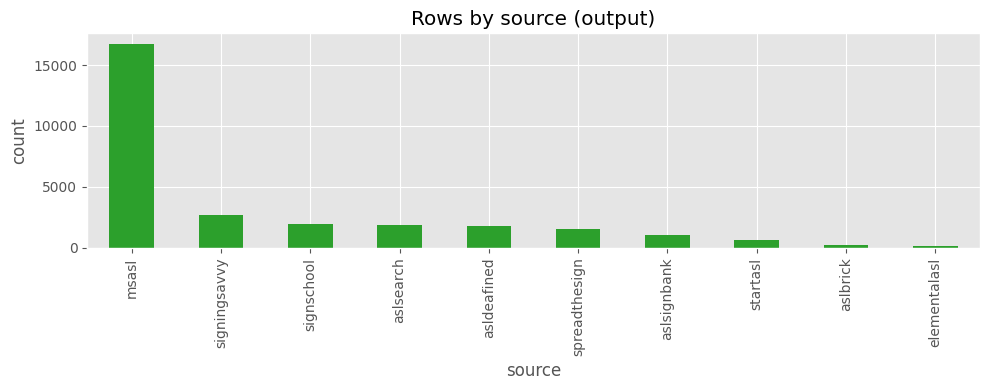

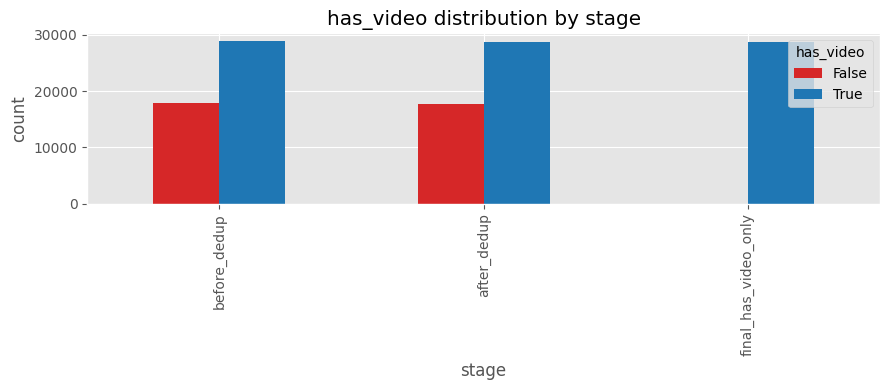

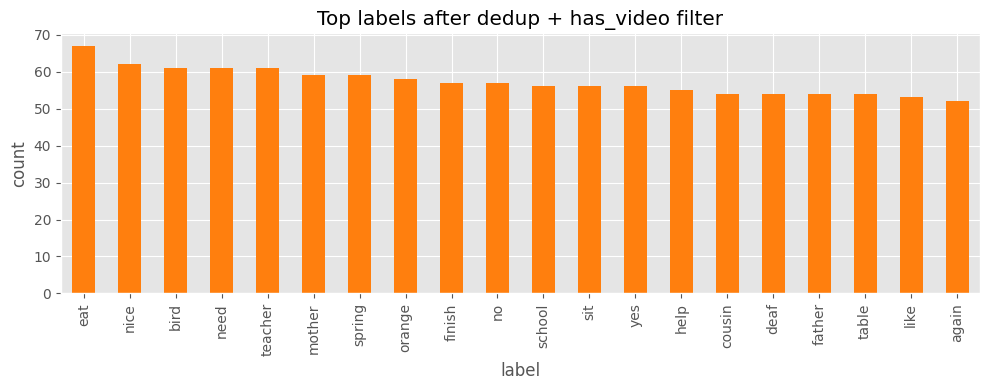

In [ ]:
plot_bar(
    df_has_video['source'].value_counts(dropna=False),
    title='Rows by source (output)',
    xlabel='source',
    ylabel='count',
    color='#2ca02c'
 )

fig, ax = plt.subplots(figsize=(9, 4))
has_video_stage.T.plot(kind='bar', ax=ax, color=['#d62728', '#1f77b4'])
ax.set_title('has_video distribution by stage')
ax.set_xlabel('stage')
ax.set_ylabel('count')
ax.legend(title='has_video')
plt.tight_layout()
plt.show()

plot_bar(
    df_has_video['label'].astype(str).str.strip().str.lower().value_counts(),
    title='Top labels after dedup + has_video filter',
    xlabel='label',
    ylabel='count',
    top_n=20,
    color='#ff7f0e'
 )

In [13]:
print('Preview output rows (first/last 5)')
display(df_has_video.head(5))
display(df_has_video.tail(5))

Preview output rows (first/last 5)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
1,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,3523,3609.0,87.0,3.440,25.00,msasl_172,True,640.0,360.0
3,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_R_ES8RZua1g...,675,734.0,60.0,1.967,30.00,msasl_40,True,568.0,320.0
6,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_VcRx3U-HpTE...,8111,8197.0,87.0,3.583,24.00,msasl_125,True,1280.0,720.0
8,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,4840,4881.0,42.0,1.368,29.97,msasl_26,True,1280.0,720.0
9,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,5514,5545.0,32.0,1.034,29.97,msasl_26,True,1280.0,720.0


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
46590,ﬁnish,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_Vintf-DLWq0...,615,658.0,44.0,1.439,29.878,msasl_41,True,202.0,360.0
46592,ﬁshing,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IRa2wGdUm1A...,3378,3423.0,46.0,1.500,30.000,msasl_41,True,202.0,360.0
46593,ﬁshing,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IRa2wGdUm1A...,3452,3508.0,57.0,1.866,30.000,msasl_41,True,202.0,360.0
46594,ﬂoor,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_eeHS78JyN70...,12209,12386.0,178.0,5.906,29.970,msasl_80,True,640.0,360.0
46595,ﬂower,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_eeHS78JyN70...,20223,20410.0,188.0,6.240,29.970,msasl_80,True,640.0,360.0


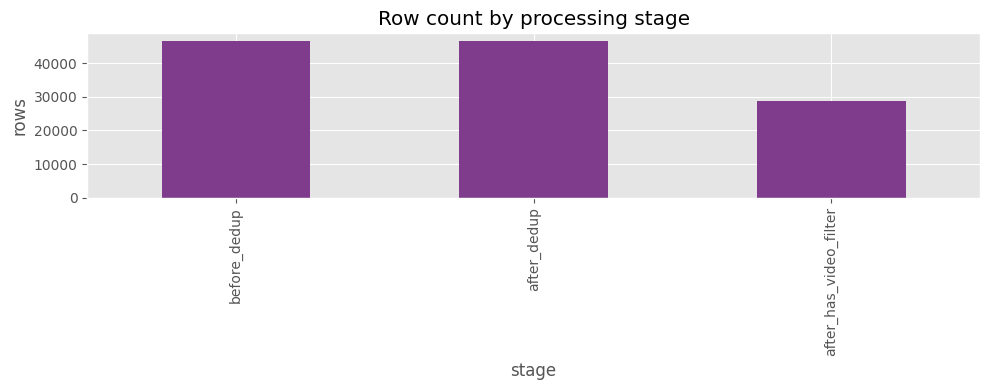

In [14]:
stage_rows = pd.Series({
    'before_dedup': rows_before,
    'after_dedup': rows_after_dedup,
    'after_has_video_filter': rows_after_has_video,
})
plot_bar(
    stage_rows,
    title='Row count by processing stage',
    xlabel='stage',
    ylabel='rows',
    color='#7f3c8d'
 )